### MaRs spectrum normalization

To allow the comparison of signal intensities MaRs normalize the output spectrum intensity to the reference intensity

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import math
from importlib import reload

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import mars

In [2]:
dtype = torch.float64

g_interaction = mars.spin_model.Interaction(2.002, dtype=dtype)
freq = 9.8 * 1e9
gauss = 1e-3
lorentz = 1e-3
temp = 293.0

spin_system = mars.spin_model.SpinSystem(
    electrons=[1/2],
    g_tensors=[g_interaction],
    dtype=dtype,
)

sample = mars.spin_model.MultiOrientedSample(
    base_spin_system=spin_system,
    gauss=gauss,
    lorentz=lorentz,
    dtype=dtype,
    mesh=(20, 20)
)

computational_details = mars.spectra_manager.ComputationalDetails(res_field_r_tol=1e-4)

spectra_creator = mars.spectra_manager.StationarySpectra(
    computational_details=computational_details,
    harmonic=0,
    sample=sample,
    freq=freq,
    temperature=temp,
    dtype=dtype,
)

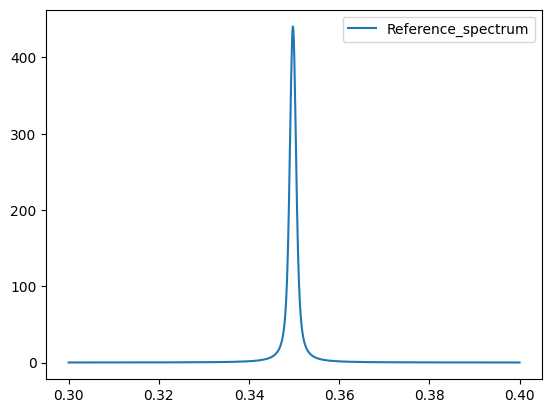

In [7]:
fields = torch.linspace(0.30, 0.40, 1000, dtype=dtype)
spectrum = spectra_creator(sample, fields=fields)
dH = fields[1] - fields[0] 
plt.plot(fields, spectrum, "-", label="Reference_spectrum")
plt.legend()

In [8]:
tot_sum = spectrum.sum(dim=-1) * (fields[1] - fields[0])
print("total sum must be equal to 1.0")
print(f"tot_sum {tot_sum}")

total sum must be equal to 1.0
tot_sum 1.0000339301694459
